In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn

In [2]:
df = pd.read_csv("./water_quality_processed.csv")

In [3]:
df.head()

,Well_ID,State,District,Block,Village,Latitude,Longitude,Year,pH,EC,...,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification
0,W254029084355301,Himachal Pradesh,Solan,nallagarh,jagatpur,31.159400,76.678500,2019,8.44,5.703782,...,1.308333,4.442651,2.890372,2.397895,3.688879,1.223775,0.182322,5.572154,85.80466,Good
1,W193530074180001,Maharashtra,Ahmednagar,sangamner,kokangaon,74.300000,19.591667,2022,7.90,7.182352,...,2.954910,6.144186,4.396915,4.180522,4.492001,0.955511,0.425268,5.921578,280.04130,Very Poor yet Drinkable
2,W251908084361501,Himachal Pradesh,Solan,nallagarh,baruna,31.154000,76.638400,2019,8.40,5.602119,...,2.397895,4.762174,2.397895,2.944439,3.178054,0.693147,0.113329,5.572154,81.77860,Good
3,W192600074540001,Maharashtra,Ahmednagar,nevasa,vadala bhairoba,74.900000,19.433333,2022,7.55,7.322510,...,4.169761,6.236370,4.763882,3.998201,4.578826,2.104134,0.165514,6.710523,376.42330,Unsuitable for Drinking
4,W222230071591001,Gujarat,Ahmedabad,dhandhuka,dhandhuka1,22.376073,71.987684,2020,8.20,8.899594,...,5.398163,6.525030,4.290459,4.812184,7.233455,3.806662,1.360977,8.499233,1944.80480,Unsuitable for Drinking


In [4]:
df.columns

Index(['Well_ID', 'State', 'District', 'Block', 'Village', 'Latitude',
       'Longitude', 'Year', 'pH', 'EC', 'HCO3', 'Cl', 'SO4', 'NO3', 'TH', 'Ca',
       'Mg', 'Na', 'K', 'F', 'TDS', 'WQI', 'Water Quality Classification'],
      dtype='str')

In [5]:
df.drop(['Well_ID', 'State', 'District', 'Block', 'Village'], axis=1, inplace=True) # dropping redundant features, as we already have lat/lon
df.drop(["Water Quality Classification"], axis=1, inplace=True) # not useful for predicting WQI

In [6]:
corr = df.corr()

In [7]:
corr

,Latitude,Longitude,Year,pH,EC,HCO3,Cl,SO4,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI
Latitude,1.000000,-0.005465,0.854333,0.005633,0.013385,0.120909,-0.020529,-0.040547,-0.116188,0.027744,-0.008622,0.038620,-0.008933,0.083760,0.003785,0.045802,-0.006746
Longitude,-0.005465,1.000000,0.002931,0.005896,-0.002842,-0.000751,-0.001539,0.002484,-0.001969,-0.002127,-0.001988,-0.000760,0.000179,-0.002328,0.003952,-0.002715,-0.003868
Year,0.854333,0.002931,1.000000,-0.009257,0.020016,0.097579,0.016778,-0.012043,-0.058907,0.039514,0.015493,0.037994,0.023424,0.069465,0.005186,0.073820,0.022467
pH,0.005633,0.005896,-0.009257,1.000000,0.116622,0.187580,0.034712,0.101086,-0.107069,0.055778,-0.030725,0.104279,0.149672,0.100404,0.140730,0.034082,0.015422
EC,0.013385,-0.002842,0.020016,0.116622,1.000000,0.751662,0.863985,0.703633,0.495022,0.881334,0.725067,0.799129,0.861438,0.347052,0.407646,0.700873,0.746555
HCO3,0.120909,-0.000751,0.097579,0.187580,0.751662,1.000000,0.480623,0.410187,0.258314,0.751849,0.620593,0.669503,0.610838,0.210357,0.365998,0.515978,0.416617
Cl,-0.020529,-0.001539,0.016778,0.034712,0.863985,0.480623,1.000000,0.647547,0.466388,0.744540,0.602385,0.688360,0.816248,0.372332,0.329064,0.627156,0.730889
SO4,-0.040547,0.002484,-0.012043,0.101086,0.703633,0.410187,0.647547,1.000000,0.434739,0.606653,0.468934,0.582897,0.651095,0.303231,0.390247,0.504815,0.562858
NO3,-0.116188,-0.001969,-0.058907,-0.107069,0.495022,0.258314,0.466388,0.434739,1.000000,0.468423,0.434285,0.386219,0.404335,0.130543,0.209802,0.372640,0.333862
TH,0.027744,-0.002127,0.039514,0.055778,0.881334,0.751849,0.744540,0.606653,0.468423,1.000000,0.847912,0.874839,0.625918,0.233358,0.312408,0.625983,0.623676


Saved → correlation_heatmap.png


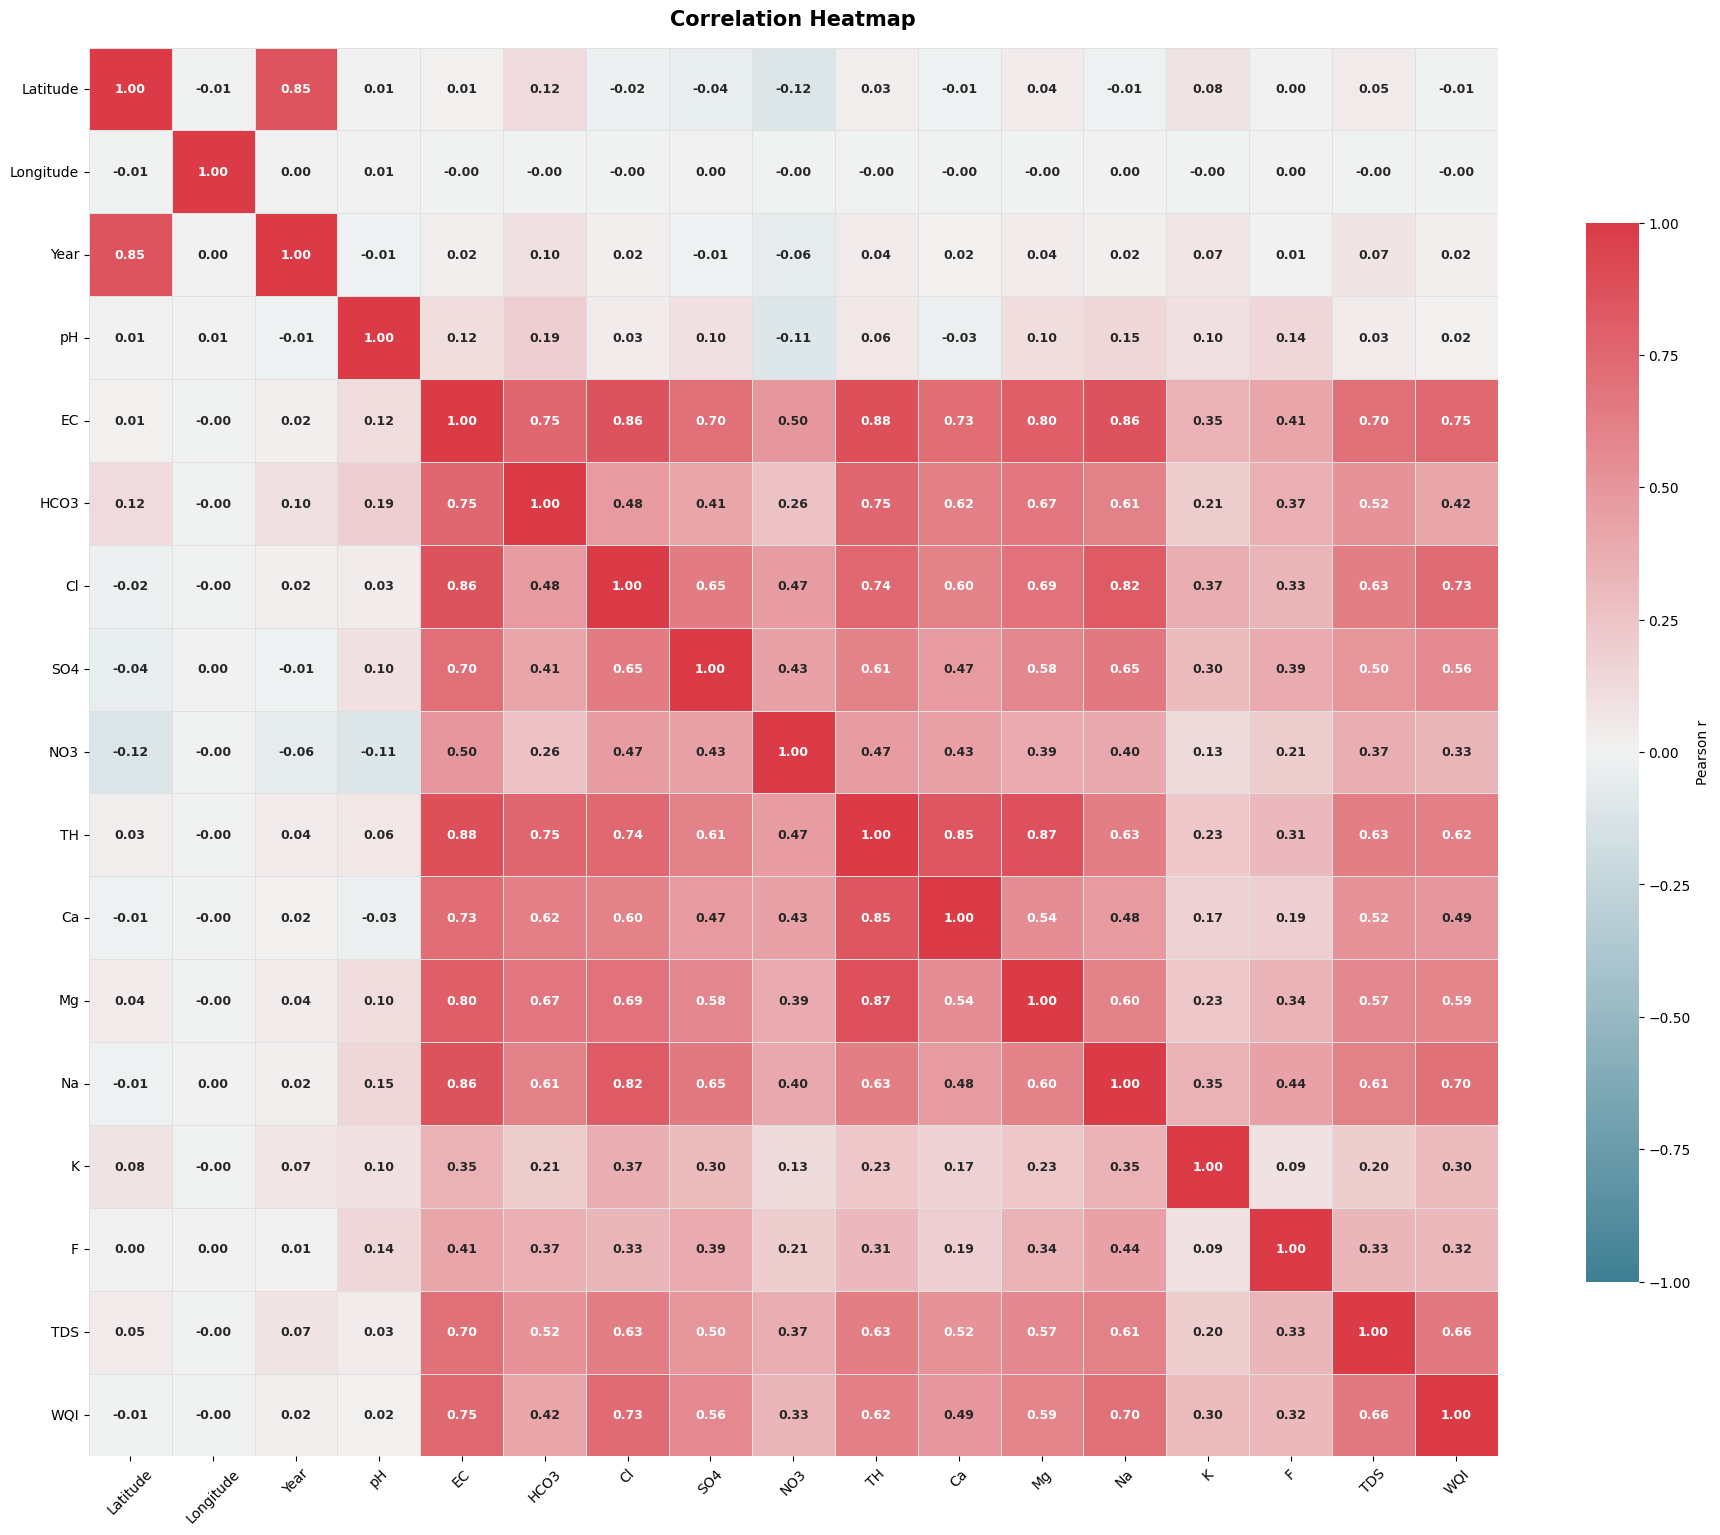

In [8]:
n = len(corr)
fig, ax = plt.subplots(figsize=(max(8, n * 1.1), max(6, n * 0.9)))
 
# Diverging palette: blue (negative) → white → red (positive)
cmap = sns.diverging_palette(220, 10, as_cmap=True)
 
mask = np.zeros_like(corr, dtype=bool)          # show full matrix
# Uncomment next line to hide the upper triangle:
# mask[np.triu_indices_from(mask)] = True
 
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f",
    annot_kws={"size": 9, "weight": "bold"},
    linewidths=0.5, linecolor="#e0e0e0",
    square=True,
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
    ax=ax,
)
 
# Titles & labels
ax.set_title("Correlation Heatmap", fontsize=15, fontweight="bold", pad=16)
ax.tick_params(axis="x", labelrotation=45, labelsize=10)
ax.tick_params(axis="y", labelrotation=0,  labelsize=10)
 
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
print("Saved → correlation_heatmap.png")
plt.show()

In [9]:
df.columns

Index(['Latitude', 'Longitude', 'Year', 'pH', 'EC', 'HCO3', 'Cl', 'SO4', 'NO3',
       'TH', 'Ca', 'Mg', 'Na', 'K', 'F', 'TDS', 'WQI'],
      dtype='str')

In [10]:
# we are dropping features, because of the multicollinearity
features = ['Latitude', 'Longitude', 'Year', 'pH', 'EC', 'Cl', 'Na', 'HCO3', 'SO4', 'NO3', 'K', 'F']
target ="WQI"

In [11]:
X = df[features]
y = df['WQI']

print(X.shape)
print(y.shape)

(14493, 12)
(14493,)


In [12]:
X.describe()

,Latitude,Longitude,Year,pH,EC,Cl,Na,HCO3,SO4,NO3,K,F
count,14493.000000,1.449300e+04,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000
mean,42.233266,5.144861e+03,2020.533016,7.709810,6.728953,4.387403,4.103654,5.469345,3.390232,2.814516,1.744239,0.408233
std,29.117081,6.125580e+05,1.305614,0.479403,0.842433,1.151295,1.079858,0.809371,1.316601,1.389103,1.105034,0.281685
min,0.000000,0.000000e+00,2019.000000,3.060000,1.190888,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.174353
25%,21.185556,2.305344e+01,2019.000000,7.450000,6.318608,3.583519,3.427515,5.214936,2.708050,1.840550,0.955511,0.190620
50%,24.362000,7.496900e+01,2021.000000,7.700000,6.778785,4.369448,4.127134,5.648974,3.465736,3.034953,1.458615,0.364643
75%,77.013611,7.846670e+01,2022.000000,7.990000,7.226936,5.141664,4.779123,5.969986,4.219508,3.804438,2.312535,0.576613
max,95.899167,7.374400e+07,2022.000000,10.610000,10.185692,9.128913,8.610684,8.043342,8.000014,7.336872,7.210818,1.360977


In [13]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
scaler = StandardScaler()
scaler.fit(x_train)

x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [15]:
print(x_train.shape, x_test.shape)

(11594, 12) (2899, 12)


In [ ]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)

In [23]:
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled  = y_scaler.transform(y_test.values.reshape(-1, 1))

y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test_scaled, dtype=torch.float32)

In [24]:
class WaterQualityModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(x_train_tensor.shape[1], 128)
        self.layer2 = nn.Linear(128, 32)
        self.layer3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

In [25]:
model = WaterQualityModel()
model

WaterQualityModel(
  (layer1): Linear(in_features=12, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

In [27]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 1000

for epoch in range(epochs):
    model.train()

    # 1. forward pass
    predictions = model(x_train_tensor)
    # 2. compute loss
    loss = criterion(predictions, y_train_tensor)
    # 3. zero gradients
    optimizer.zero_grad()
    # 4. backward pass
    loss.backward()
    # 5. update weights
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_preds = model(x_test_tensor)
        test_loss  = criterion(test_preds, y_test_tensor)

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f}")

Epoch 0 | Train Loss: 1.2112 | Test Loss: 1.2932
Epoch 100 | Train Loss: 0.1512 | Test Loss: 0.1943
Epoch 200 | Train Loss: 0.0660 | Test Loss: 0.0976
Epoch 300 | Train Loss: 0.0388 | Test Loss: 0.0626
Epoch 400 | Train Loss: 0.0277 | Test Loss: 0.0481
Epoch 500 | Train Loss: 0.0226 | Test Loss: 0.0410
Epoch 600 | Train Loss: 0.0197 | Test Loss: 0.0378
Epoch 700 | Train Loss: 0.0180 | Test Loss: 0.0354
Epoch 800 | Train Loss: 0.0169 | Test Loss: 0.0344
Epoch 900 | Train Loss: 0.0160 | Test Loss: 0.0339


In [29]:
import math
rmse = math.sqrt(loss.item())
print(f"RMSE: {rmse:.4f}")

rmse_actual = rmse * y_scaler.scale_[0]
print(f"RMSE in WQI units: {rmse_actual:.2f}")

RMSE: 0.1242
RMSE in WQI units: 34.39


In [31]:
model.eval()
with torch.no_grad():
    predictions = model(x_test_tensor)
    
# convert back to original WQI scale
predictions_actual = y_scaler.inverse_transform(predictions.numpy())
y_actual = y_scaler.inverse_transform(y_test_tensor.numpy())

# create comparison dataframe
results = pd.DataFrame({
    'Actual WQI':    y_actual.flatten(),
    'Predicted WQI': predictions_actual.flatten(),
    'Error':         abs(y_actual.flatten() - predictions_actual.flatten())
})

print(results.head(10))
print(f"\nMean Absolute Error: {results['Error'].mean():.2f}")

   Actual WQI  Predicted WQI      Error
0  298.453644     312.999603  14.545959
1  527.593811     578.019531  50.425720
2  105.214783     104.134888   1.079895
3  108.050217      99.561646   8.488571
4  185.987549     251.452377  65.464828
5  108.496460     176.078857  67.582397
6  305.195435     324.185272  18.989838
7  172.809753     265.552917  92.743164
8  444.122375     416.846436  27.275940
9  495.340698     467.919312  27.421387

Mean Absolute Error: 24.12


In [33]:
df = pd.read_csv("./water_quality_processed.csv")

In [38]:
df.groupby("Water Quality Classification")["WQI"].describe()

,count,mean,std,min,25%,50%,75%,max
Water Quality Classification,,,,,,,,
Excellent,507.0,35.291320,10.003726,9.694329,28.512570,36.59620,43.422803,49.95470
Good,1074.0,77.008185,14.809998,50.026635,64.676783,78.17852,90.169058,99.92520
Poor,3925.0,152.517605,28.920976,100.052660,126.763740,154.73550,177.871600,199.99532
Unsuitable for Drinking,5114.0,527.362314,365.335188,300.011380,347.344065,417.93563,564.549405,6850.88872
Very Poor yet Drinkable,3873.0,246.061799,28.564163,200.032940,221.365200,243.64638,269.939320,299.99592


In [41]:
def classify_wqi(wqi):
    if wqi < 50:
        return "Excellent"
    elif wqi < 100:
        return "Good"
    elif wqi < 200:
        return "Poor"
    elif wqi < 300:
        return "Very Poor yet Drinkable"
    else:
        return "Unsuitable for Drinking"

In [43]:
wq_classifier = [classify_wqi(i) for i in predictions_actual]

In [61]:
for i in zip(predictions_actual.flatten().tolist(), wq_classifier):
    print(i)

(312.9996032714844, 'Unsuitable for Drinking')
(578.01953125, 'Unsuitable for Drinking')
(104.1348876953125, 'Poor')
(99.5616455078125, 'Good')
(251.45237731933594, 'Very Poor yet Drinkable')
(176.078857421875, 'Poor')
(324.1852722167969, 'Unsuitable for Drinking')
(265.55291748046875, 'Very Poor yet Drinkable')
(416.846435546875, 'Unsuitable for Drinking')
(467.9193115234375, 'Unsuitable for Drinking')
(257.8262023925781, 'Very Poor yet Drinkable')
(344.9480285644531, 'Unsuitable for Drinking')
(279.2672424316406, 'Very Poor yet Drinkable')
(649.9849853515625, 'Unsuitable for Drinking')
(361.1003723144531, 'Unsuitable for Drinking')
(429.86566162109375, 'Unsuitable for Drinking')
(476.42327880859375, 'Unsuitable for Drinking')
(51.33265686035156, 'Good')
(187.65382385253906, 'Poor')
(223.3376007080078, 'Very Poor yet Drinkable')
(48.31666564941406, 'Excellent')
(187.26510620117188, 'Poor')
(252.7537078857422, 'Very Poor yet Drinkable')
(294.3320617675781, 'Very Poor yet Drinkable')
(3